---
## Exercise 1: K-Means Clustering (Built-in Library)

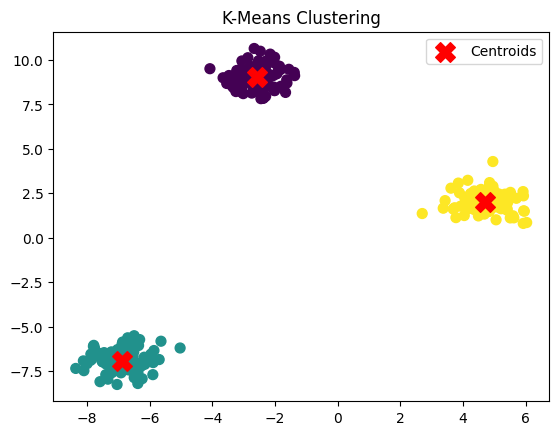

Saved: kmeans_output.png


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

# Generate dataset
X, y_true = make_blobs(n_samples=300, centers=3, cluster_std=0.6, random_state=42)

# Apply K-Means
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X)

labels = kmeans.labels_
centers = kmeans.cluster_centers_

# Plot
plt.scatter(X[:, 0], X[:, 1], c=labels, s=50, cmap='viridis')
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, marker='X', label='Centroids')
plt.title("K-Means Clustering")
plt.legend()
plt.savefig("kmeans_output.png")
plt.show()
print("Saved: kmeans_output.png")

---
## Exercise 2: Elbow Method

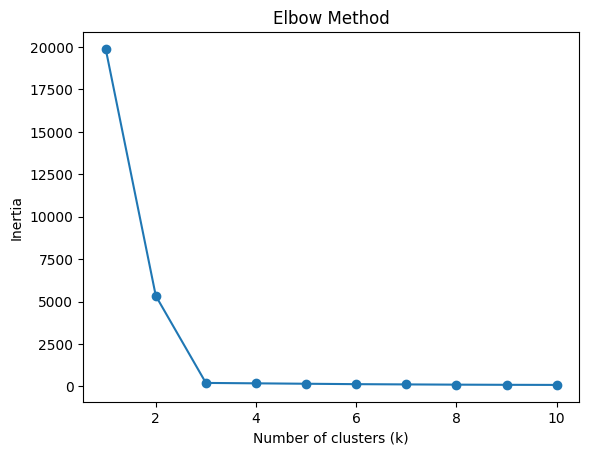

Saved: elbow_plot.png


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

# Same dataset
X, _ = make_blobs(n_samples=300, centers=3, cluster_std=0.6, random_state=42)

# Compute inertia for k = 1 to 10
inertia = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X)
    inertia.append(km.inertia_)

# Plot elbow curve
plt.plot(range(1, 11), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.savefig("elbow_plot.png")
plt.show()
print("Saved: elbow_plot.png")

---
## Exercise 3: K-Medoids Clustering (PAM Algorithm)

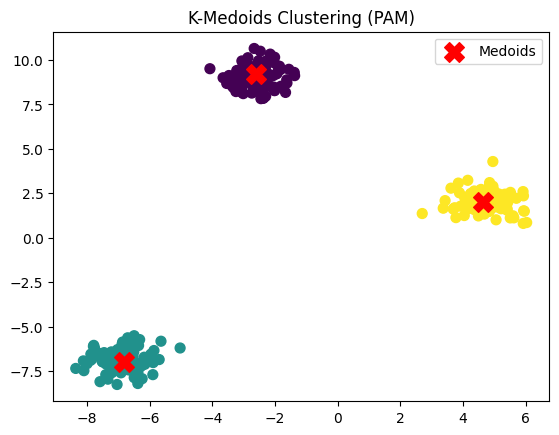

Saved: kmedoids_output.png


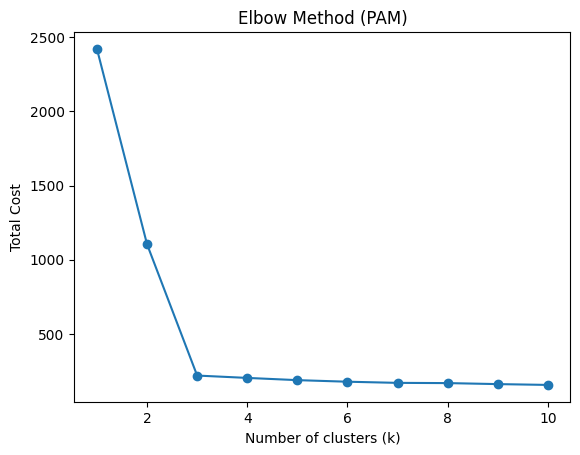

In [3]:
# scikit-learn-extra breaks on NumPy 2.x in Colab, so we implement PAM from scratch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

def pam_kmedoids(X, k, random_state=42):
    np.random.seed(random_state)
    # BUILD: pick k random medoid indices
    medoid_idx = np.random.choice(len(X), k, replace=False)

    # Compute full distance matrix once
    dist = np.linalg.norm(X[:, None] - X[None, :], axis=2)  # (n, n)

    for _ in range(100):
        # Assign each point to nearest medoid
        labels = np.argmin(dist[:, medoid_idx], axis=1)

        # SWAP: try replacing each medoid with a better point
        new_medoid_idx = medoid_idx.copy()
        for j in range(k):
            cluster_pts = np.where(labels == j)[0]
            # Pick the point in this cluster with minimum total distance to others
            best = cluster_pts[np.argmin(dist[cluster_pts][:, cluster_pts].sum(axis=1))]
            new_medoid_idx[j] = best

        if np.all(new_medoid_idx == medoid_idx):
            break
        medoid_idx = new_medoid_idx

    labels = np.argmin(dist[:, medoid_idx], axis=1)
    total_cost = dist[np.arange(len(X)), medoid_idx[labels]].sum()
    return medoid_idx, labels, total_cost

# Generate dataset
X, _ = make_blobs(n_samples=300, centers=3, cluster_std=0.6, random_state=42)

# Apply K-Medoids (PAM)
medoid_idx, labels, _ = pam_kmedoids(X, k=3)
medoids = X[medoid_idx]

# Plot clustered data
plt.scatter(X[:, 0], X[:, 1], c=labels, s=50, cmap='viridis')
plt.scatter(medoids[:, 0], medoids[:, 1], c='red', s=200, marker='X', label='Medoids')
plt.title("K-Medoids Clustering (PAM)")
plt.legend()
plt.savefig("kmedoids_output.png")
plt.show()
print("Saved: kmedoids_output.png")

# Elbow Method for K-Medoids
cost = []
for k in range(1, 11):
    _, _, c = pam_kmedoids(X, k=k)
    cost.append(c)

plt.plot(range(1, 11), cost, marker='o')
plt.title("Elbow Method (PAM)")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Total Cost")
plt.show()

---
## Exercise 4: K-Means from Scratch

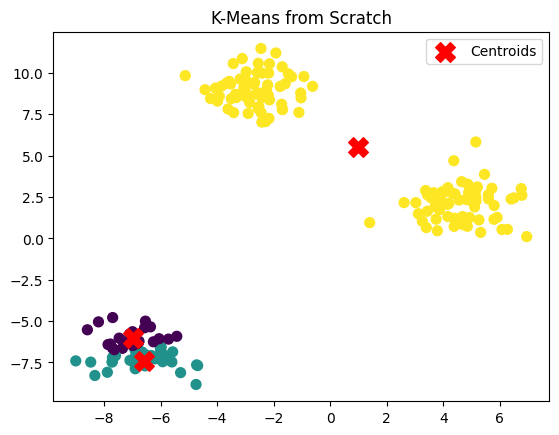

Saved: kmeans_scratch.png


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# Generate dataset
X, _ = make_blobs(n_samples=200, centers=3, random_state=42)

k = 3
max_iters = 100

# Randomly pick 3 points as initial centroids
np.random.seed(42)
indices = np.random.choice(len(X), k, replace=False)
centroids = X[indices]

labels = np.zeros(len(X), dtype=int)

for _ in range(max_iters):
    # Assign each point to the nearest centroid
    for i, point in enumerate(X):
        distances = [np.linalg.norm(point - c) for c in centroids]
        labels[i] = np.argmin(distances)

    # Update centroids
    new_centroids = np.array([X[labels == j].mean(axis=0) for j in range(k)])

    # Stop if centroids didn't change
    if np.allclose(centroids, new_centroids):
        break

    centroids = new_centroids

# Plot results
plt.scatter(X[:, 0], X[:, 1], c=labels, s=50, cmap='viridis')
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=200, marker='X', label='Centroids')
plt.title("K-Means from Scratch")
plt.legend()
plt.savefig("kmeans_scratch.png")
plt.show()
print("Saved: kmeans_scratch.png")